In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# 1. Simulation Parameters
dt = 0.01
t_max = 1000.0
time_steps = int(t_max / dt)
t = np.linspace(0, t_max, time_steps)

# Oscillator parameters
mu = 1.0
omega0 = 1.0

# Coupling and Delay parameters
coupling = 0.2
delay = 2.0
delay_steps = int(delay / dt)

# Noise parameter (Langevin)
noise_intensity = 0.1

# Initialize arrays for state variables
# x1, y1 (Oscillator 1) and x2, y2 (Oscillator 2)
x1 = np.zeros(time_steps)
y1 = np.zeros(time_steps)
x2 = np.zeros(time_steps)
y2 = np.zeros(time_steps)

# Initial conditions (historical states before t=0 set to small random values)
x1[:delay_steps+1] = np.random.normal(0, 0.1, delay_steps+1)
y1[:delay_steps+1] = np.random.normal(0, 0.1, delay_steps+1)
x2[:delay_steps+1] = np.random.normal(0, 0.1, delay_steps+1)
y2[:delay_steps+1] = np.random.normal(0, 0.1, delay_steps+1)

# 2. Euler-Maruyama Integration with Delay
for i in range(delay_steps, time_steps - 1):
    # Delayed states
    x1_delayed = x1[i - delay_steps]
    x2_delayed = x2[i - delay_steps]

    # Langevin equations
    dx1 = y1[i] * dt
    dy1 = (mu * (1.0 - x1[i]**2) * y1[i] - (omega0**2) * x1[i] + coupling * (x2_delayed - x1[i])) * dt + noise_intensity * np.sqrt(dt) * np.random.normal()

    dx2 = y2[i] * dt
    dy2 = (mu * (1.0 - x2[i]**2) * y2[i] - (omega0**2) * x2[i] + coupling * (x1_delayed - x2[i])) * dt + noise_intensity * np.sqrt(dt) * np.random.normal()

    x1[i+1] = x1[i] + dx1
    y1[i+1] = y1[i] + dy1
    x2[i+1] = x2[i] + dx2
    y2[i+1] = y2[i] + dy2

# 3. Extract Period Time Series
# Identify peaks in x1 to find the periods
peaks, _ = find_peaks(x1, height=0.5, distance=int(3.0/dt))
peak_times = t[peaks]
periods = np.diff(peak_times)

print(f"Extracted {len(periods)} periods from Oscillator 1.")

Extracted 154 periods from Oscillator 1.


In [5]:
# 4. Detrended Fluctuation Analysis (DFA)
def dfa(time_series, scales):
    # Integrate the time series
    y = np.cumsum(time_series - np.mean(time_series))
    N = len(time_series)
    fluctuations = []

    for scale in scales:
        num_segments = N // scale
        scale_fluctuations = []

        for segment in range(num_segments):
            start = segment * scale
            end = start + scale
            x_segment = np.arange(scale)
            y_segment = y[start:end]

            # Fit a linear trend to the segment
            coeff = np.polyfit(x_segment, y_segment, 1)
            trend = np.polyval(coeff, x_segment)

            # Calculate fluctuation
            scale_fluctuations.append(np.mean((y_segment - trend) ** 2))

        fluctuations.append(np.sqrt(np.mean(scale_fluctuations)))

    return np.array(fluctuations)

# Select scales (box sizes)
min_scale = 10
max_scale = len(periods) // 4
scales = np.unique(np.logspace(np.log10(min_scale), np.log10(max_scale), num=20, dtype=int))

# Run DFA
fluctuations = dfa(periods, scales)

# Estimate alpha (scaling exponent) using linear fit on log-log scales
poly = np.polyfit(np.log10(scales), np.log10(fluctuations), 1)
alpha = poly[0]
print(f"Estimated DFA exponent (alpha): {alpha:.3f}")

Estimated DFA exponent (alpha): 0.476


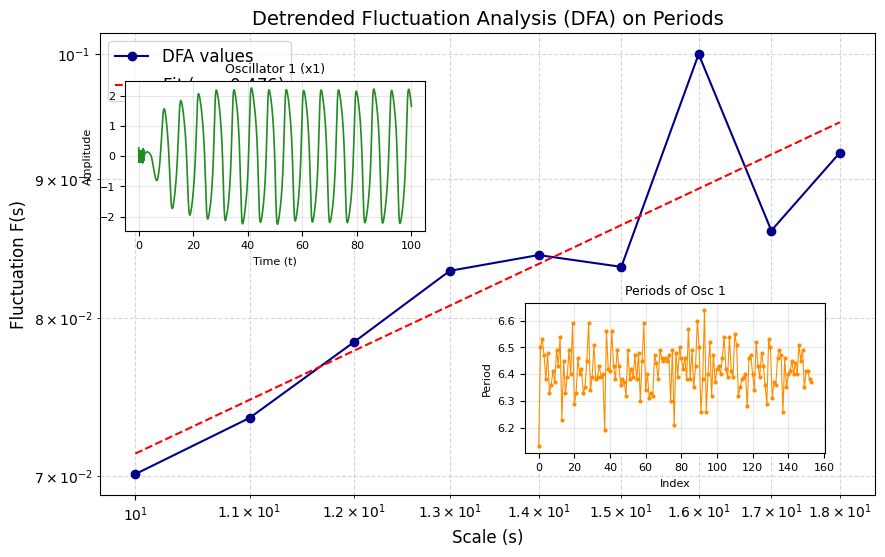

In [10]:
# 5. Visualization with Inset Plots
fig, ax = plt.subplots(figsize=(10, 6))

# Main Plot: DFA on periods
ax.loglog(scales, fluctuations, 'o-', color='darkblue', label='DFA values')
fit_line = 10**poly[1] * (scales**alpha)
# Fix: Use a raw f-string (fr) to prevent interpretation of \alpha as an ASCII bell character
ax.loglog(scales, fit_line, 'r--', label=fr'Fit ($\alpha$ = {alpha:.3f})')
ax.set_title("Detrended Fluctuation Analysis (DFA) on Periods", fontsize=14)
ax.set_xlabel("Scale (s)", fontsize=12)
ax.set_ylabel("Fluctuation F(s)", fontsize=12)
ax.grid(True, which="both", ls="--", alpha=0.5)
ax.legend(fontsize=12)

# Inset 1: Oscillator 1 Time Series (State variable x1)
inset1 = fig.add_axes([0.15, 0.55, 0.3, 0.25])  # [left, bottom, width, height]
inset1.plot(t[t < 100], x1[t < 100], color='forestgreen', lw=1.2)
inset1.set_title("Oscillator 1 (x1)", fontsize=9)
inset1.set_xlabel("Time (t)", fontsize=8)
inset1.set_ylabel("Amplitude", fontsize=8)
inset1.tick_params(labelsize=8)
inset1.grid(True, alpha=0.3)

# Inset 2: Periods Time Series
inset2 = fig.add_axes([0.55, 0.18, 0.3, 0.25])
inset2.plot(periods, color='darkorange', marker='.', markersize=4, lw=0.8)
inset2.set_title("Periods of Osc 1", fontsize=9)
inset2.set_xlabel("Index", fontsize=8)
inset2.set_ylabel("Period", fontsize=8)
inset2.tick_params(labelsize=8)
inset2.grid(True, alpha=0.3)

plt.show()

Starting delay sweep to calculate DFA alpha...
Delay: 0.50 s | DFA alpha: 0.388
Delay: 1.00 s | DFA alpha: 0.230
Delay: 1.50 s | DFA alpha: 0.387
Delay: 2.00 s | DFA alpha: 0.503
Delay: 2.50 s | DFA alpha: 1.068
Delay: 3.00 s | DFA alpha: 0.281
Delay: 3.50 s | DFA alpha: 2.251
Delay: 4.00 s | DFA alpha: 0.337
Delay: 4.50 s | DFA alpha: 0.406
Delay: 5.00 s | DFA alpha: 0.202


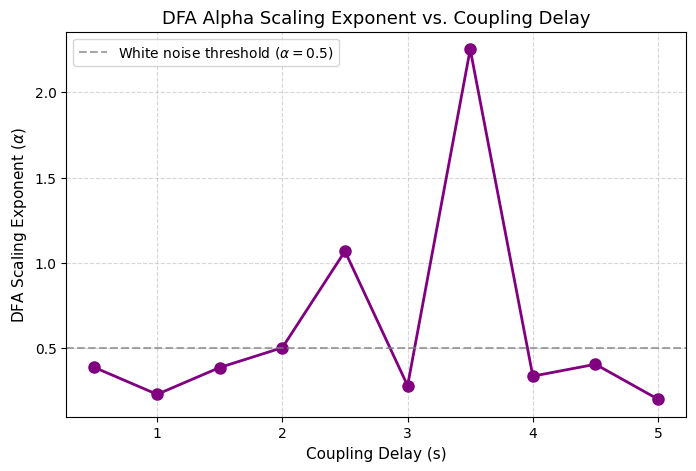

In [12]:
# Define a range of delays to sweep
delays_to_sweep = np.linspace(0.5, 5.0, 10)
alphas = []

# Keep simulation configurations consistent
dt_sweep = 0.01
t_max_sweep = 600.0
time_steps_sweep = int(t_max_sweep / dt_sweep)
t_sweep_arr = np.linspace(0, t_max_sweep, time_steps_sweep)
mu = 1.0
omega0 = 1.0
coupling = 0.2
noise_intensity = 0.1

print("Starting delay sweep to calculate DFA alpha...")

for d_val in delays_to_sweep:
    delay_steps_s = int(d_val / dt_sweep)

    # Initialize state variables
    x1_s = np.zeros(time_steps_sweep)
    y1_s = np.zeros(time_steps_sweep)
    x2_s = np.zeros(time_steps_sweep)
    y2_s = np.zeros(time_steps_sweep)

    x1_s[:delay_steps_s+1] = np.random.normal(0, 0.1, delay_steps_s+1)
    y1_s[:delay_steps_s+1] = np.random.normal(0, 0.1, delay_steps_s+1)
    x2_s[:delay_steps_s+1] = np.random.normal(0, 0.1, delay_steps_s+1)
    y2_s[:delay_steps_s+1] = np.random.normal(0, 0.1, delay_steps_s+1)

    # Integrate
    for i in range(delay_steps_s, time_steps_sweep - 1):
        x1_delayed = x1_s[i - delay_steps_s]
        x2_delayed = x2_s[i - delay_steps_s]

        dx1 = y1_s[i] * dt_sweep
        dy1 = (mu * (1.0 - x1_s[i]**2) * y1_s[i] - (omega0**2) * x1_s[i] + coupling * (x2_delayed - x1_s[i])) * dt_sweep + noise_intensity * np.sqrt(dt_sweep) * np.random.normal()

        dx2 = y2_s[i] * dt_sweep
        dy2 = (mu * (1.0 - x2_s[i]**2) * y2_s[i] - (omega0**2) * x2_s[i] + coupling * (x1_delayed - x2_s[i])) * dt_sweep + noise_intensity * np.sqrt(dt_sweep) * np.random.normal()

        x1_s[i+1] = x1_s[i] + dx1
        y1_s[i+1] = y1_s[i] + dy1
        x2_s[i+1] = x2_s[i] + dx2
        y2_s[i+1] = y2_s[i] + dy2

    # Extract Periods
    peaks_s, _ = find_peaks(x1_s, height=0.5, distance=int(3.0/dt_sweep))
    peak_times_s = t_sweep_arr[peaks_s]
    periods_s = np.diff(peak_times_s)

    # DFA execution on extracted periods
    min_scale_s = 10
    max_scale_s = len(periods_s) // 4
    if max_scale_s > min_scale_s:
        scales_s = np.unique(np.logspace(np.log10(min_scale_s), np.log10(max_scale_s), num=15, dtype=int))
        fluct_s = dfa(periods_s, scales_s)
        poly_s = np.polyfit(np.log10(scales_s), np.log10(fluct_s), 1)
        alphas.append(poly_s[0])
    else:
        alphas.append(np.nan)
    print(f"Delay: {d_val:.2f} s | DFA alpha: {alphas[-1]:.3f}")

# Plotting results
plt.figure(figsize=(8, 5))
plt.plot(delays_to_sweep, alphas, 'o-', color='purple', linewidth=2, markersize=8)
plt.title("DFA Alpha Scaling Exponent vs. Coupling Delay", fontsize=13)
plt.xlabel("Coupling Delay (s)", fontsize=11)
# Fix: Use raw string (fr) to avoid parsing error with \alpha
plt.ylabel(fr"DFA Scaling Exponent ($\alpha$)", fontsize=11)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label=r'White noise threshold ($\alpha=0.5$)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

Starting fine-grained delay sweep around resonance (2.0s - 4.0s)...
Delay: 2.000 s | DFA alpha: 0.481
Delay: 2.143 s | DFA alpha: 0.156
Delay: 2.286 s | DFA alpha: 0.206
Delay: 2.429 s | DFA alpha: 0.297
Delay: 2.571 s | DFA alpha: 0.435
Delay: 2.714 s | DFA alpha: 0.289
Delay: 2.857 s | DFA alpha: 0.490
Delay: 3.000 s | DFA alpha: 0.274
Delay: 3.143 s | DFA alpha: 0.423
Delay: 3.286 s | DFA alpha: 0.654
Delay: 3.429 s | DFA alpha: 0.569
Delay: 3.571 s | DFA alpha: 0.191
Delay: 3.714 s | DFA alpha: 0.249
Delay: 3.857 s | DFA alpha: 0.265
Delay: 4.000 s | DFA alpha: 0.185


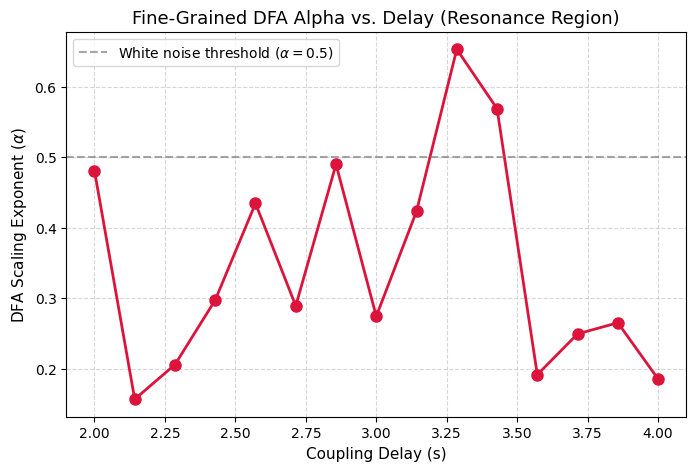

In [13]:
# Finer delay sweep around the resonance regions (2.0 to 4.0 seconds)
delays_fine = np.linspace(2.0, 4.0, 15)
alphas_fine = []

dt_sweep = 0.01
t_max_sweep = 600.0
time_steps_sweep = int(t_max_sweep / dt_sweep)
t_sweep_arr = np.linspace(0, t_max_sweep, time_steps_sweep)
mu = 1.0
omega0 = 1.0
coupling = 0.2
noise_intensity = 0.1

print("Starting fine-grained delay sweep around resonance (2.0s - 4.0s)...")

for d_val in delays_fine:
    delay_steps_s = int(d_val / dt_sweep)

    x1_s = np.zeros(time_steps_sweep)
    y1_s = np.zeros(time_steps_sweep)
    x2_s = np.zeros(time_steps_sweep)
    y2_s = np.zeros(time_steps_sweep)

    x1_s[:delay_steps_s+1] = np.random.normal(0, 0.1, delay_steps_s+1)
    y1_s[:delay_steps_s+1] = np.random.normal(0, 0.1, delay_steps_s+1)
    x2_s[:delay_steps_s+1] = np.random.normal(0, 0.1, delay_steps_s+1)
    y2_s[:delay_steps_s+1] = np.random.normal(0, 0.1, delay_steps_s+1)

    for i in range(delay_steps_s, time_steps_sweep - 1):
        x1_delayed = x1_s[i - delay_steps_s]
        x2_delayed = x2_s[i - delay_steps_s]

        dx1 = y1_s[i] * dt_sweep
        dy1 = (mu * (1.0 - x1_s[i]**2) * y1_s[i] - (omega0**2) * x1_s[i] + coupling * (x2_delayed - x1_s[i])) * dt_sweep + noise_intensity * np.sqrt(dt_sweep) * np.random.normal()

        dx2 = y2_s[i] * dt_sweep
        dy2 = (mu * (1.0 - x2_s[i]**2) * y2_s[i] - (omega0**2) * x2_s[i] + coupling * (x1_delayed - x2_s[i])) * dt_sweep + noise_intensity * np.sqrt(dt_sweep) * np.random.normal()

        x1_s[i+1] = x1_s[i] + dx1
        y1_s[i+1] = y1_s[i] + dy1
        x2_s[i+1] = x2_s[i] + dx2
        y2_s[i+1] = y2_s[i] + dy2

    peaks_s, _ = find_peaks(x1_s, height=0.5, distance=int(3.0/dt_sweep))
    peak_times_s = t_sweep_arr[peaks_s]
    periods_s = np.diff(peak_times_s)

    min_scale_s = 10
    max_scale_s = len(periods_s) // 4
    if max_scale_s > min_scale_s:
        scales_s = np.unique(np.logspace(np.log10(min_scale_s), np.log10(max_scale_s), num=15, dtype=int))
        fluct_s = dfa(periods_s, scales_s)
        poly_s = np.polyfit(np.log10(scales_s), np.log10(fluct_s), 1)
        alphas_fine.append(poly_s[0])
    else:
        alphas_fine.append(np.nan)
    print(f"Delay: {d_val:.3f} s | DFA alpha: {alphas_fine[-1]:.3f}")

# Plotting fine-grained results
plt.figure(figsize=(8, 5))
plt.plot(delays_fine, alphas_fine, 'o-', color='crimson', linewidth=2, markersize=8)
plt.title("Fine-Grained DFA Alpha vs. Delay (Resonance Region)", fontsize=13)
plt.xlabel("Coupling Delay (s)", fontsize=11)
plt.ylabel(fr"DFA Scaling Exponent ($\alpha$)", fontsize=11)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label=r'White noise threshold ($\alpha=0.5$)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()